# Exploratory Data Analysis (EDA) - Data Mining

Notebook ini berisi analisis eksplorasi data untuk dataset donasi masjid yang mencakup:
- Nilai n (banyak bin)
- Value per bin
- Nilai N (min, max, avg)
- Metadata campaign (N, campaign_duration, target_dana)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import json

# Setting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data dari JSON (dengan Metadata Campaign)

In [2]:
# Load semua file JSON dari folder dataset/JSON
json_path = '../dataset/JSON/'
json_files = glob.glob(os.path.join(json_path, '*.json'))

print(f"Jumlah file JSON ditemukan: {len(json_files)}")
print("\nDaftar file:")
for f in json_files:
    print(f"  - {os.path.basename(f)}")

Jumlah file JSON ditemukan: 22

Daftar file:
  - donors_masjidkemasjid_20251221_025520.json
  - donors_pembangunanmasjidtapalbatas_20251221_125448.json
  - donors_pahalajariyahwakafpembangunanmasjid_20251221_092111.json
  - donors_maribantupembangunanmasjiddipedalamansumsel_20251221_125320.json
  - donors_amaljariyahpembangunanmasjidalmuniri_20251221_125413.json
  - donors_maribangunmasjidjatisarigisikdrono_20251221_091657.json
  - donors_sedekahmasjidpantaibali_20251221_124938.json
  - donors_masjidpelosoktimur_20251221_102949.json
  - donors_donasimasjidalfurqon1750_20251221_100244.json
  - donors_masjidario_20251221_124111.json
  - donors_pembangunanmasjidmuhammadiyahalmujahidin_20251221_124431.json
  - donors_masjidrumahtahfiz_20251221_124621.json
  - donors_20251221_124258.json
  - donors_pembangunanalhikmahbandarlampung_20251221_112615.json
  - donors_pembangunanmasjidpemudamandiri_20251221_112739.json
  - donors_yukkinvestasiakhirat_20251221_124729.json
  - donors_bangunmasjidpe

In [3]:
# Fungsi untuk mengekstrak nama campaign dari nama file
def extract_campaign_name(filename):
    basename = os.path.basename(filename)
    # Remove prefix 'donors_' dan suffix tanggal
    name = basename.replace('donors_', '').rsplit('_', 2)[0]
    return name

# Load semua data JSON dengan metadata
all_data = []
campaign_metadata_list = []

for file in json_files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    campaign_name = extract_campaign_name(file)
    
    # Ekstrak campaign_metadata
    metadata = data.get('campaign_metadata', {})
    metadata['campaign'] = campaign_name
    metadata['total_donors_scraped'] = data.get('total_donors_scraped', 0)
    campaign_metadata_list.append(metadata)
    
    # Ekstrak donors
    donors = data.get('donors', [])
    for donor in donors:
        donor['campaign'] = campaign_name
        donor['N'] = metadata.get('N', '')
        donor['campaign_duration'] = metadata.get('campaign_duration', '')
        donor['target_dana'] = metadata.get('target_dana', '')
        all_data.append(donor)

# Buat DataFrame
df_donors = pd.DataFrame(all_data)
df_metadata = pd.DataFrame(campaign_metadata_list)

print(f"\nTotal data donors: {len(df_donors)} baris")
print(f"Total campaigns: {len(df_metadata)} campaigns")


Total data donors: 25140 baris
Total campaigns: 22 campaigns


In [4]:
# Lihat sample data donors
print("Sample Data Donors:")
df_donors.head(10)

Sample Data Donors:


,name,amount,time_ago,campaign,N,campaign_duration,target_dana
0,Orang Baik,Rp25.000,13 hari yang lalu,masjidkemasjid,7020,10 hari lagi,Rp250.000.000
1,Achyar tapianus,Rp50.000,19 hari yang lalu,masjidkemasjid,7020,10 hari lagi,Rp250.000.000
2,Orang Baik,Rp100.000,22 hari yang lalu,masjidkemasjid,7020,10 hari lagi,Rp250.000.000
3,Orang Baik,Rp50.000,2 bulan yang lalu,masjidkemasjid,7020,10 hari lagi,Rp250.000.000
4,Yuyun,Rp50.000,2 bulan yang lalu,masjidkemasjid,7020,10 hari lagi,Rp250.000.000
5,Orang Baik,Rp1.000,2 bulan yang lalu,masjidkemasjid,7020,10 hari lagi,Rp250.000.000
6,yofy kurniawan,Rp5.000,2 bulan yang lalu,masjidkemasjid,7020,10 hari lagi,Rp250.000.000
7,s,Rp1.000,2 bulan yang lalu,masjidkemasjid,7020,10 hari lagi,Rp250.000.000
8,Orang Baik,Rp10.000,2 bulan yang lalu,masjidkemasjid,7020,10 hari lagi,Rp250.000.000
9,Jdkdkk,Rp50.000,2 bulan yang lalu,masjidkemasjid,7020,10 hari lagi,Rp250.000.000


In [5]:
# Lihat metadata campaign
print("Metadata Campaign:")
df_metadata

Metadata Campaign:


,N,campaign_duration,target_dana,campaign,total_donors_scraped
0,7020,10 hari lagi,Rp250.000.000,masjidkemasjid,7020
1,69,100 (days remaining only),Rp1.000.000.000,pembangunanmasjidtapalbatas,69
2,632,71 (days remaining only),Rp100.000.000,pahalajariyahwakafpembangunanmasjid,632
3,125,375 (days remaining only),Rp1.651.080.000,maribantupembangunanmasjiddipedalamansumsel,125
4,94,41 (days remaining only),Rp1.226.500.000,amaljariyahpembangunanmasjidalmuniri,94
5,1675,740 (days remaining only),Rp500.000.000,maribangunmasjidjatisarigisikdrono,1675
6,1851,0 (days remaining only),Rp200.000.000,sedekahmasjidpantaibali,1851
7,5206,0 (days remaining only),Rp100.000.000,masjidpelosoktimur,5204
8,133,740 (days remaining only),Rp1.750.000.000,donasimasjidalfurqon1750,133
9,306,8 (days remaining only),Rp116.650.000,masjidario,306


## 2. Data Preprocessing

In [6]:
# Fungsi untuk konversi format Rupiah ke angka
def convert_rupiah_to_number(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return value
    # Hapus 'Rp', titik, dan spasi
    cleaned = str(value).replace('Rp', '').replace('.', '').replace(',', '').strip()
    try:
        return float(cleaned)
    except:
        return np.nan

# Konversi kolom amount
df_donors['amount_numeric'] = df_donors['amount'].apply(convert_rupiah_to_number)

# Konversi kolom target_dana
df_donors['target_numeric'] = df_donors['target_dana'].apply(convert_rupiah_to_number)

# Konversi kolom N ke numeric
df_donors['N_numeric'] = pd.to_numeric(df_donors['N'], errors='coerce')

print("Contoh hasil konversi:")
df_donors[['amount', 'amount_numeric', 'N', 'N_numeric', 'target_dana', 'target_numeric']].head(10)

Contoh hasil konversi:


,amount,amount_numeric,N,N_numeric,target_dana,target_numeric
0,Rp25.000,25000.0,7020,7020,Rp250.000.000,250000000.0
1,Rp50.000,50000.0,7020,7020,Rp250.000.000,250000000.0
2,Rp100.000,100000.0,7020,7020,Rp250.000.000,250000000.0
3,Rp50.000,50000.0,7020,7020,Rp250.000.000,250000000.0
4,Rp50.000,50000.0,7020,7020,Rp250.000.000,250000000.0
5,Rp1.000,1000.0,7020,7020,Rp250.000.000,250000000.0
6,Rp5.000,5000.0,7020,7020,Rp250.000.000,250000000.0
7,Rp1.000,1000.0,7020,7020,Rp250.000.000,250000000.0
8,Rp10.000,10000.0,7020,7020,Rp250.000.000,250000000.0
9,Rp50.000,50000.0,7020,7020,Rp250.000.000,250000000.0


In [7]:
# Preprocessing metadata
df_metadata['N_numeric'] = pd.to_numeric(df_metadata['N'], errors='coerce')
df_metadata['target_numeric'] = df_metadata['target_dana'].apply(convert_rupiah_to_number)

print("Metadata setelah preprocessing:")
df_metadata[['campaign', 'N', 'N_numeric', 'campaign_duration', 'target_dana', 'target_numeric']]

Metadata setelah preprocessing:


,campaign,N,N_numeric,campaign_duration,target_dana,target_numeric
0,masjidkemasjid,7020,7020,10 hari lagi,Rp250.000.000,2.500000e+08
1,pembangunanmasjidtapalbatas,69,69,100 (days remaining only),Rp1.000.000.000,1.000000e+09
2,pahalajariyahwakafpembangunanmasjid,632,632,71 (days remaining only),Rp100.000.000,1.000000e+08
3,maribantupembangunanmasjiddipedalamansumsel,125,125,375 (days remaining only),Rp1.651.080.000,1.651080e+09
4,amaljariyahpembangunanmasjidalmuniri,94,94,41 (days remaining only),Rp1.226.500.000,1.226500e+09
5,maribangunmasjidjatisarigisikdrono,1675,1675,740 (days remaining only),Rp500.000.000,5.000000e+08
6,sedekahmasjidpantaibali,1851,1851,0 (days remaining only),Rp200.000.000,2.000000e+08
7,masjidpelosoktimur,5206,5206,0 (days remaining only),Rp100.000.000,1.000000e+08
8,donasimasjidalfurqon1750,133,133,740 (days remaining only),Rp1.750.000.000,1.750000e+09
9,masjidario,306,306,8 (days remaining only),Rp116.650.000,1.166500e+08


In [8]:
# Hapus data dengan amount yang tidak valid
df_clean = df_donors.dropna(subset=['amount_numeric'])
df_clean = df_clean[df_clean['amount_numeric'] > 0]

print(f"Data sebelum cleaning: {len(df_donors)}")
print(f"Data setelah cleaning: {len(df_clean)}")
print(f"Data yang dihapus: {len(df_donors) - len(df_clean)}")

Data sebelum cleaning: 25140
Data setelah cleaning: 25140
Data yang dihapus: 0


## 3. Statistik Campaign Metadata (N, Campaign Duration, Target Dana)

In [9]:
print("="*80)
print("STATISTIK CAMPAIGN METADATA")
print("="*80)

print(f"\n--- Statistik N (Jumlah Donatur per Campaign) ---")
print(f"Total Campaign      : {len(df_metadata)}")
print(f"Min N               : {df_metadata['N_numeric'].min():,.0f}")
print(f"Max N               : {df_metadata['N_numeric'].max():,.0f}")
print(f"Average N           : {df_metadata['N_numeric'].mean():,.2f}")
print(f"Median N            : {df_metadata['N_numeric'].median():,.0f}")
print(f"Total N (semua)     : {df_metadata['N_numeric'].sum():,.0f}")

print(f"\n--- Statistik Target Dana ---")
print(f"Min Target          : Rp {df_metadata['target_numeric'].min():,.0f}")
print(f"Max Target          : Rp {df_metadata['target_numeric'].max():,.0f}")
print(f"Average Target      : Rp {df_metadata['target_numeric'].mean():,.2f}")
print(f"Total Target        : Rp {df_metadata['target_numeric'].sum():,.0f}")

STATISTIK CAMPAIGN METADATA

--- Statistik N (Jumlah Donatur per Campaign) ---
Total Campaign      : 22
Min N               : 69
Max N               : 7,020
Average N           : 1,289.14
Median N            : 551
Total N (semua)     : 28,361

--- Statistik Target Dana ---
Min Target          : Rp 10,000,000
Max Target          : Rp 2,500,000,000,000
Average Target      : Rp 114,347,010,454.55
Total Target        : Rp 2,515,634,230,000


In [10]:
# Tabel lengkap metadata campaign
print("\n" + "="*80)
print("DETAIL METADATA PER CAMPAIGN")
print("="*80 + "\n")

metadata_display = df_metadata[['campaign', 'N_numeric', 'campaign_duration', 'target_numeric']].copy()
metadata_display.columns = ['Campaign', 'N (Donatur)', 'Duration', 'Target Dana']
metadata_display = metadata_display.sort_values('N (Donatur)', ascending=False)
metadata_display


DETAIL METADATA PER CAMPAIGN



,Campaign,N (Donatur),Duration,Target Dana
0,masjidkemasjid,7020,10 hari lagi,2.500000e+08
7,masjidpelosoktimur,5206,0 (days remaining only),1.000000e+08
16,bangunmasjidpelosok25,3974,0 (days remaining only),1.000000e+08
6,sedekahmasjidpantaibali,1851,0 (days remaining only),2.000000e+08
5,maribangunmasjidjatisarigisikdrono,1675,740 (days remaining only),5.000000e+08
21,pembangunanmasjidalbina,1590,0 (days remaining only),2.500000e+12
13,pembangunanalhikmahbandarlampung,1040,0 (days remaining only),1.000000e+08
11,masjidrumahtahfiz,999,3417 (days remaining only),5.000000e+09
20,masjidalakbarsorong,961,375 (days remaining only),2.000000e+09
2,pahalajariyahwakafpembangunanmasjid,632,71 (days remaining only),1.000000e+08


## 4. Statistik Dasar - Nilai Donasi (Min, Max, Avg)

In [11]:
# Statistik deskriptif untuk amount_numeric
print("="*60)
print("STATISTIK DONASI (amount_numeric)")
print("="*60)

print(f"\nTotal Transaksi      : {len(df_clean):,}")
print(f"Minimum              : Rp {df_clean['amount_numeric'].min():,.0f}")
print(f"Maximum              : Rp {df_clean['amount_numeric'].max():,.0f}")
print(f"Average (Mean)       : Rp {df_clean['amount_numeric'].mean():,.2f}")
print(f"Median               : Rp {df_clean['amount_numeric'].median():,.0f}")
print(f"Standard Deviation   : Rp {df_clean['amount_numeric'].std():,.2f}")
print(f"Total Amount         : Rp {df_clean['amount_numeric'].sum():,.0f}")

STATISTIK DONASI (amount_numeric)

Total Transaksi      : 25,140
Minimum              : Rp 1,000
Maximum              : Rp 10,000,000
Average (Mean)       : Rp 14,939.84
Median               : Rp 2,000
Standard Deviation   : Rp 136,300.66
Total Amount         : Rp 375,587,611


In [12]:
# Statistik per campaign
print("\n" + "="*80)
print("STATISTIK DONASI PER CAMPAIGN")
print("="*80)

stats_per_campaign = df_clean.groupby('campaign').agg({
    'amount_numeric': ['count', 'min', 'max', 'mean', 'median', 'sum'],
    'N_numeric': 'first',
    'target_numeric': 'first',
    'campaign_duration': 'first'
}).round(2)

stats_per_campaign.columns = ['Count', 'Min', 'Max', 'Average', 'Median', 'Total', 'N', 'Target', 'Duration']
stats_per_campaign = stats_per_campaign.sort_values('Total', ascending=False)
stats_per_campaign


STATISTIK DONASI PER CAMPAIGN


,Count,Min,Max,Average,Median,Total,N,Target,Duration
campaign,,,,,,,,,
masjidpelosoktimur,5204,1000.0,5000000.0,11564.59,5000.0,60182144.0,5206,1.000000e+08,0 (days remaining only)
maribangunmasjidjatisarigisikdrono,1675,1000.0,10000000.0,24604.18,5000.0,41212000.0,1675,5.000000e+08,740 (days remaining only)
masjidalakbarsorong,961,1000.0,10000000.0,38457.80,3000.0,36957947.0,961,2.000000e+09,375 (days remaining only)
masjidkemasjid,7020,1000.0,500000.0,4154.69,1000.0,29165955.0,7020,2.500000e+08,10 hari lagi
masjidrumahtahfiz,999,1000.0,4000000.0,28944.98,5000.0,28916034.0,999,5.000000e+09,3417 (days remaining only)
setarapulihkanmasjid,354,1000.0,10000000.0,68073.81,5000.0,24098127.0,354,1.000000e+08,10 (days remaining only)
pembangunanmasjidalbina,1590,1000.0,3135000.0,15028.54,3000.0,23895372.0,1590,2.500000e+12,0 (days remaining only)
sedekahmasjidpantaibali,1851,1000.0,2000000.0,12697.46,5000.0,23503000.0,1851,2.000000e+08,0 (days remaining only)
pahalajariyahwakafpembangunanmasjid,632,1000.0,4000000.0,30588.61,5000.0,19332000.0,632,1.000000e+08,71 (days remaining only)


## 5. Binning Analysis - Nilai n dan Value per Bin

In [13]:
# Tentukan jumlah bin (n)
# Menggunakan berbagai metode untuk menentukan jumlah bin optimal

data = df_clean['amount_numeric'].values

# Metode 1: Sturges' Rule
n_sturges = int(np.ceil(np.log2(len(data)) + 1))

# Metode 2: Square Root Rule
n_sqrt = int(np.ceil(np.sqrt(len(data))))

# Metode 3: Rice Rule
n_rice = int(np.ceil(2 * (len(data) ** (1/3))))

# Metode 4: Freedman-Diaconis Rule
iqr = np.percentile(data, 75) - np.percentile(data, 25)
bin_width_fd = 2 * iqr * (len(data) ** (-1/3))
n_fd = int(np.ceil((data.max() - data.min()) / bin_width_fd)) if bin_width_fd > 0 else 10

print("="*60)
print("PENENTUAN JUMLAH BIN (n)")
print("="*60)
print(f"\nJumlah Data: {len(data):,}")
print(f"\nMetode penentuan jumlah bin:")
print(f"  1. Sturges' Rule        : n = {n_sturges}")
print(f"  2. Square Root Rule     : n = {n_sqrt}")
print(f"  3. Rice Rule            : n = {n_rice}")
print(f"  4. Freedman-Diaconis    : n = {n_fd}")

PENENTUAN JUMLAH BIN (n)

Jumlah Data: 25,140

Metode penentuan jumlah bin:
  1. Sturges' Rule        : n = 16
  2. Square Root Rule     : n = 159
  3. Rice Rule            : n = 59
  4. Freedman-Diaconis    : n = 18308


In [14]:
# Gunakan beberapa nilai n untuk analisis
n_bins_list = [5, 10, 15, 20, n_sturges]

print("\n" + "="*80)
print("ANALISIS BINNING DENGAN BERBAGAI NILAI n")
print("="*80)

for n_bins in n_bins_list:
    print(f"\n{'─'*80}")
    print(f"n = {n_bins} bins")
    print(f"{'─'*80}")
    
    # Buat bins dengan equal-width binning
    bins = pd.cut(df_clean['amount_numeric'], bins=n_bins)
    bin_analysis = df_clean.groupby(bins, observed=True)['amount_numeric'].agg([
        ('Count', 'count'),
        ('Min', 'min'),
        ('Max', 'max'),
        ('Mean', 'mean'),
        ('Sum', 'sum')
    ]).round(2)
    
    bin_analysis['Percentage'] = (bin_analysis['Count'] / len(df_clean) * 100).round(2)
    
    print(bin_analysis.to_string())


ANALISIS BINNING DENGAN BERBAGAI NILAI n

────────────────────────────────────────────────────────────────────────────────
n = 5 bins
────────────────────────────────────────────────────────────────────────────────
                         Count         Min         Max         Mean          Sum  Percentage
amount_numeric                                                                              
(-8999.0, 2000800.0]     25129      1000.0   2000000.0     12693.01  318962611.0       99.96
(2000800.0, 4000600.0]       7   2400000.0   4000000.0   3089285.71   21625000.0        0.03
(4000600.0, 6000400.0]       1   5000000.0   5000000.0   5000000.00    5000000.0        0.00
(8000200.0, 10000000.0]      3  10000000.0  10000000.0  10000000.00   30000000.0        0.01

────────────────────────────────────────────────────────────────────────────────
n = 10 bins
────────────────────────────────────────────────────────────────────────────────
                         Count         Min         

In [15]:
# Equal-Frequency Binning (Quantile-based)
print("\n" + "="*80)
print("EQUAL-FREQUENCY BINNING (Quantile-based)")
print("="*80)

n_quantile_bins = 10
print(f"\nn = {n_quantile_bins} bins (berdasarkan quantile)")
print(f"{'─'*80}")

# Buat quantile bins
df_clean['quantile_bin'] = pd.qcut(df_clean['amount_numeric'], q=n_quantile_bins, duplicates='drop')

quantile_analysis = df_clean.groupby('quantile_bin', observed=True)['amount_numeric'].agg([
    ('Count', 'count'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Mean', 'mean'),
    ('Sum', 'sum')
]).round(2)

quantile_analysis['Percentage'] = (quantile_analysis['Count'] / len(df_clean) * 100).round(2)

print(quantile_analysis.to_string())


EQUAL-FREQUENCY BINNING (Quantile-based)

n = 10 bins (berdasarkan quantile)
────────────────────────────────────────────────────────────────────────────────
                       Count      Min         Max       Mean          Sum  Percentage
quantile_bin                                                                         
(999.999, 2000.0]      13299   1000.0      2000.0    1213.25   16135000.0       52.90
(2000.0, 5000.0]        5297   3000.0      5000.0    4561.26   24161000.0       21.07
(5000.0, 10000.0]       2516   6000.0     10000.0    9686.80   24372000.0       10.01
(10000.0, 25000.0]      1801  10020.0     25000.0   19518.25   35152372.0        7.16
(25000.0, 10000000.0]   2227  25172.0  10000000.0  123829.03  275767239.0        8.86


In [16]:
# Custom bins berdasarkan kategori donasi
print("\n" + "="*80)
print("CUSTOM BINNING (Kategori Donasi)")
print("="*80)

custom_bins = [0, 10000, 25000, 50000, 100000, 250000, 500000, 1000000, float('inf')]
custom_labels = [
    '< 10rb',
    '10rb - 25rb',
    '25rb - 50rb', 
    '50rb - 100rb',
    '100rb - 250rb',
    '250rb - 500rb',
    '500rb - 1jt',
    '> 1jt'
]

df_clean['donation_category'] = pd.cut(
    df_clean['amount_numeric'], 
    bins=custom_bins, 
    labels=custom_labels,
    include_lowest=True
)

print(f"\nn = {len(custom_labels)} bins (kategori custom)")
print(f"{'─'*80}")

custom_analysis = df_clean.groupby('donation_category', observed=True)['amount_numeric'].agg([
    ('Count (N)', 'count'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Average', 'mean'),
    ('Total', 'sum')
]).round(2)

custom_analysis['Percentage'] = (custom_analysis['Count (N)'] / len(df_clean) * 100).round(2)

print(custom_analysis.to_string())


CUSTOM BINNING (Kategori Donasi)

n = 8 bins (kategori custom)
────────────────────────────────────────────────────────────────────────────────
                   Count (N)        Min         Max     Average       Total  Percentage
donation_category                                                                      
< 10rb                 21112     1000.0     10000.0     3063.09  64668000.0       83.98
10rb - 25rb             1801    10020.0     25000.0    19518.25  35152372.0        7.16
25rb - 50rb             1432    25172.0     50000.0    45691.47  65430181.0        5.70
50rb - 100rb             488    50429.0    100000.0    95106.55  46411997.0        1.94
100rb - 250rb            174   100003.0    250000.0   182578.84  31768718.0        0.69
250rb - 500rb             82   250399.0    500000.0   422202.99  34620645.0        0.33
500rb - 1jt               31   500695.0   1000000.0   872881.03  27059312.0        0.12
> 1jt                     20  1000062.0  10000000.0  3523819.30

## 6. Visualisasi

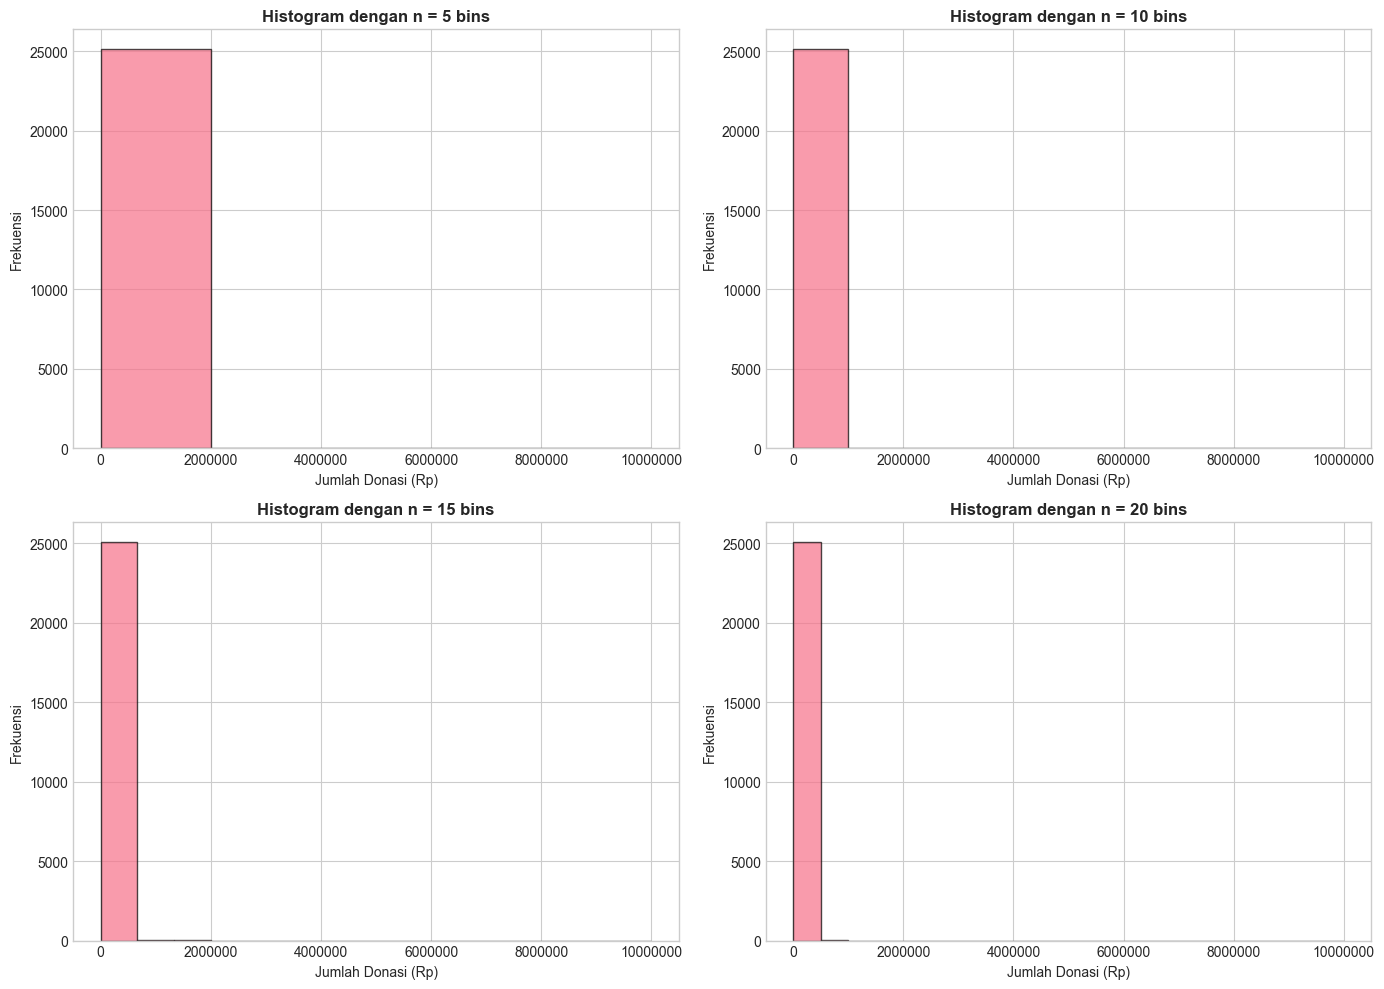

Grafik disimpan: histogram_berbagai_bins.png


In [17]:
# Histogram dengan berbagai jumlah bin
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bin_configs = [5, 10, 15, 20]

for ax, n in zip(axes.flatten(), bin_configs):
    ax.hist(df_clean['amount_numeric'], bins=n, edgecolor='black', alpha=0.7)
    ax.set_title(f'Histogram dengan n = {n} bins', fontsize=12, fontweight='bold')
    ax.set_xlabel('Jumlah Donasi (Rp)')
    ax.set_ylabel('Frekuensi')
    ax.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.savefig('histogram_berbagai_bins.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: histogram_berbagai_bins.png")

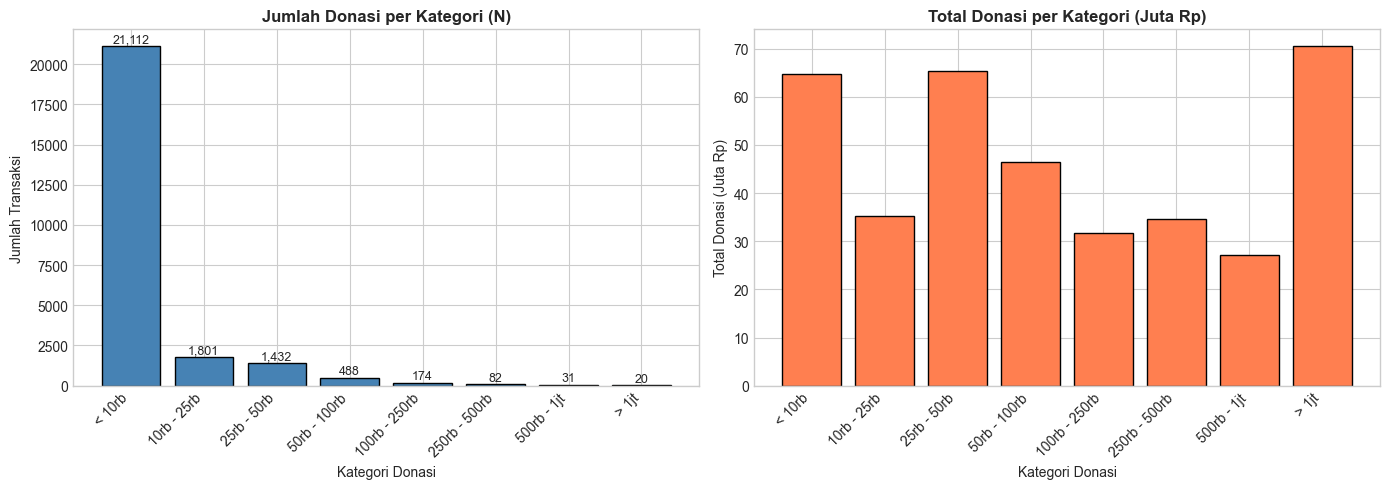

Grafik disimpan: custom_binning_analysis.png


In [18]:
# Bar chart untuk custom binning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count per category
category_counts = df_clean['donation_category'].value_counts().sort_index()
axes[0].bar(range(len(category_counts)), category_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(category_counts)))
axes[0].set_xticklabels(category_counts.index, rotation=45, ha='right')
axes[0].set_title('Jumlah Donasi per Kategori (N)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kategori Donasi')
axes[0].set_ylabel('Jumlah Transaksi')

# Tambahkan nilai di atas bar
for i, v in enumerate(category_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Total amount per category
category_sum = df_clean.groupby('donation_category', observed=True)['amount_numeric'].sum()
axes[1].bar(range(len(category_sum)), category_sum.values / 1000000, color='coral', edgecolor='black')
axes[1].set_xticks(range(len(category_sum)))
axes[1].set_xticklabels(category_sum.index, rotation=45, ha='right')
axes[1].set_title('Total Donasi per Kategori (Juta Rp)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kategori Donasi')
axes[1].set_ylabel('Total Donasi (Juta Rp)')

plt.tight_layout()
plt.savefig('custom_binning_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: custom_binning_analysis.png")

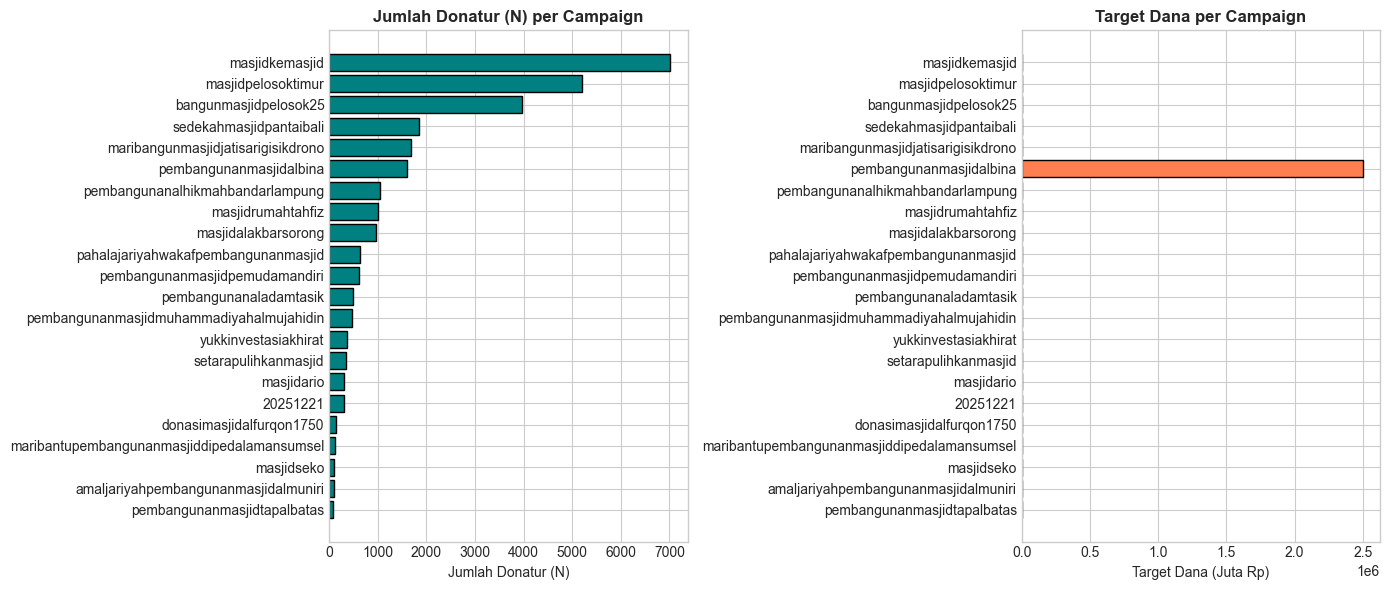

Grafik disimpan: campaign_metadata_visualization.png


In [19]:
# Visualisasi N dan Target Dana per Campaign
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sort by N
df_meta_sorted = df_metadata.sort_values('N_numeric', ascending=True)

# Bar chart N per campaign
axes[0].barh(df_meta_sorted['campaign'], df_meta_sorted['N_numeric'], color='teal', edgecolor='black')
axes[0].set_xlabel('Jumlah Donatur (N)')
axes[0].set_title('Jumlah Donatur (N) per Campaign', fontsize=12, fontweight='bold')

# Bar chart Target per campaign
axes[1].barh(df_meta_sorted['campaign'], df_meta_sorted['target_numeric']/1000000, color='coral', edgecolor='black')
axes[1].set_xlabel('Target Dana (Juta Rp)')
axes[1].set_title('Target Dana per Campaign', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('campaign_metadata_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: campaign_metadata_visualization.png")

<Figure size 1200x600 with 0 Axes>

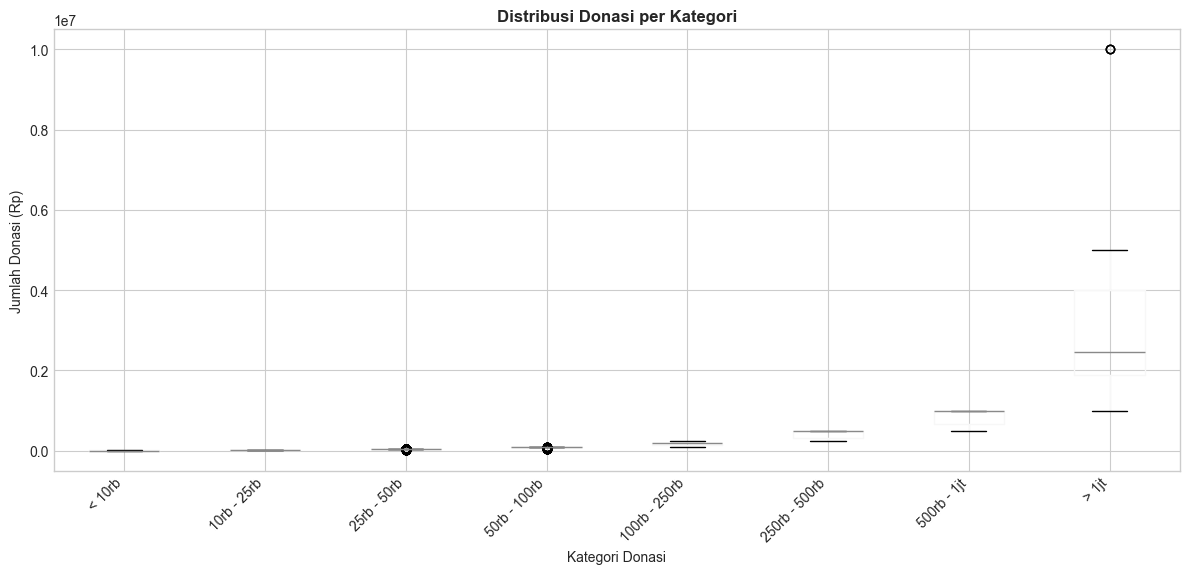

Grafik disimpan: boxplot_per_kategori.png


In [20]:
# Box plot per kategori
plt.figure(figsize=(12, 6))
df_clean.boxplot(column='amount_numeric', by='donation_category', figsize=(12, 6))
plt.title('Distribusi Donasi per Kategori', fontsize=12, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.xlabel('Kategori Donasi')
plt.ylabel('Jumlah Donasi (Rp)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('boxplot_per_kategori.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: boxplot_per_kategori.png")

## 7. Ringkasan Hasil Analisis

In [21]:
print("="*80)
print("RINGKASAN HASIL ANALISIS")
print("="*80)

print(f"""
1. DATASET OVERVIEW
   - Jumlah Campaign    : {df_metadata['campaign'].nunique()}
   - Total Transaksi    : {len(df_clean):,}
   - Total Donasi       : Rp {df_clean['amount_numeric'].sum():,.0f}

2. METADATA CAMPAIGN (N, Duration, Target)
   - Total N (Donatur)  : {df_metadata['N_numeric'].sum():,.0f}
   - Min N              : {df_metadata['N_numeric'].min():,.0f}
   - Max N              : {df_metadata['N_numeric'].max():,.0f}
   - Average N          : {df_metadata['N_numeric'].mean():,.2f}
   
   - Min Target Dana    : Rp {df_metadata['target_numeric'].min():,.0f}
   - Max Target Dana    : Rp {df_metadata['target_numeric'].max():,.0f}
   - Average Target     : Rp {df_metadata['target_numeric'].mean():,.2f}

3. STATISTIK DONASI
   - Minimum            : Rp {df_clean['amount_numeric'].min():,.0f}
   - Maximum            : Rp {df_clean['amount_numeric'].max():,.0f}
   - Average (Mean)     : Rp {df_clean['amount_numeric'].mean():,.2f}
   - Median             : Rp {df_clean['amount_numeric'].median():,.0f}

4. JUMLAH BIN (n) - Berbagai Metode
   - Sturges' Rule      : {n_sturges} bins
   - Square Root Rule   : {n_sqrt} bins
   - Rice Rule          : {n_rice} bins
   - Freedman-Diaconis  : {n_fd} bins

5. VALUE PER BIN (Custom Kategori)
""")

for idx, row in custom_analysis.iterrows():
    print(f"   {idx:15} : N={int(row['Count (N)']):,} ({row['Percentage']:.1f}%), "
          f"Min=Rp{row['Min']:,.0f}, Max=Rp{row['Max']:,.0f}, Avg=Rp{row['Average']:,.0f}")

RINGKASAN HASIL ANALISIS

1. DATASET OVERVIEW
   - Jumlah Campaign    : 22
   - Total Transaksi    : 25,140
   - Total Donasi       : Rp 375,587,611

2. METADATA CAMPAIGN (N, Duration, Target)
   - Total N (Donatur)  : 28,361
   - Min N              : 69
   - Max N              : 7,020
   - Average N          : 1,289.14

   - Min Target Dana    : Rp 10,000,000
   - Max Target Dana    : Rp 2,500,000,000,000
   - Average Target     : Rp 114,347,010,454.55

3. STATISTIK DONASI
   - Minimum            : Rp 1,000
   - Maximum            : Rp 10,000,000
   - Average (Mean)     : Rp 14,939.84
   - Median             : Rp 2,000

4. JUMLAH BIN (n) - Berbagai Metode
   - Sturges' Rule      : 16 bins
   - Square Root Rule   : 159 bins
   - Rice Rule          : 59 bins
   - Freedman-Diaconis  : 18308 bins

5. VALUE PER BIN (Custom Kategori)

   < 10rb          : N=21,112 (84.0%), Min=Rp1,000, Max=Rp10,000, Avg=Rp3,063
   10rb - 25rb     : N=1,801 (7.2%), Min=Rp10,020, Max=Rp25,000, Avg=Rp19,518
  

In [22]:
# Export hasil ke CSV
custom_analysis.to_csv('ringkasan_binning.csv')
stats_per_campaign.to_csv('statistik_per_campaign.csv')
df_metadata.to_csv('campaign_metadata.csv', index=False)

## 8. Histogram Distribusi Amount (Tanpa Binning Manual, Semua Campaign)

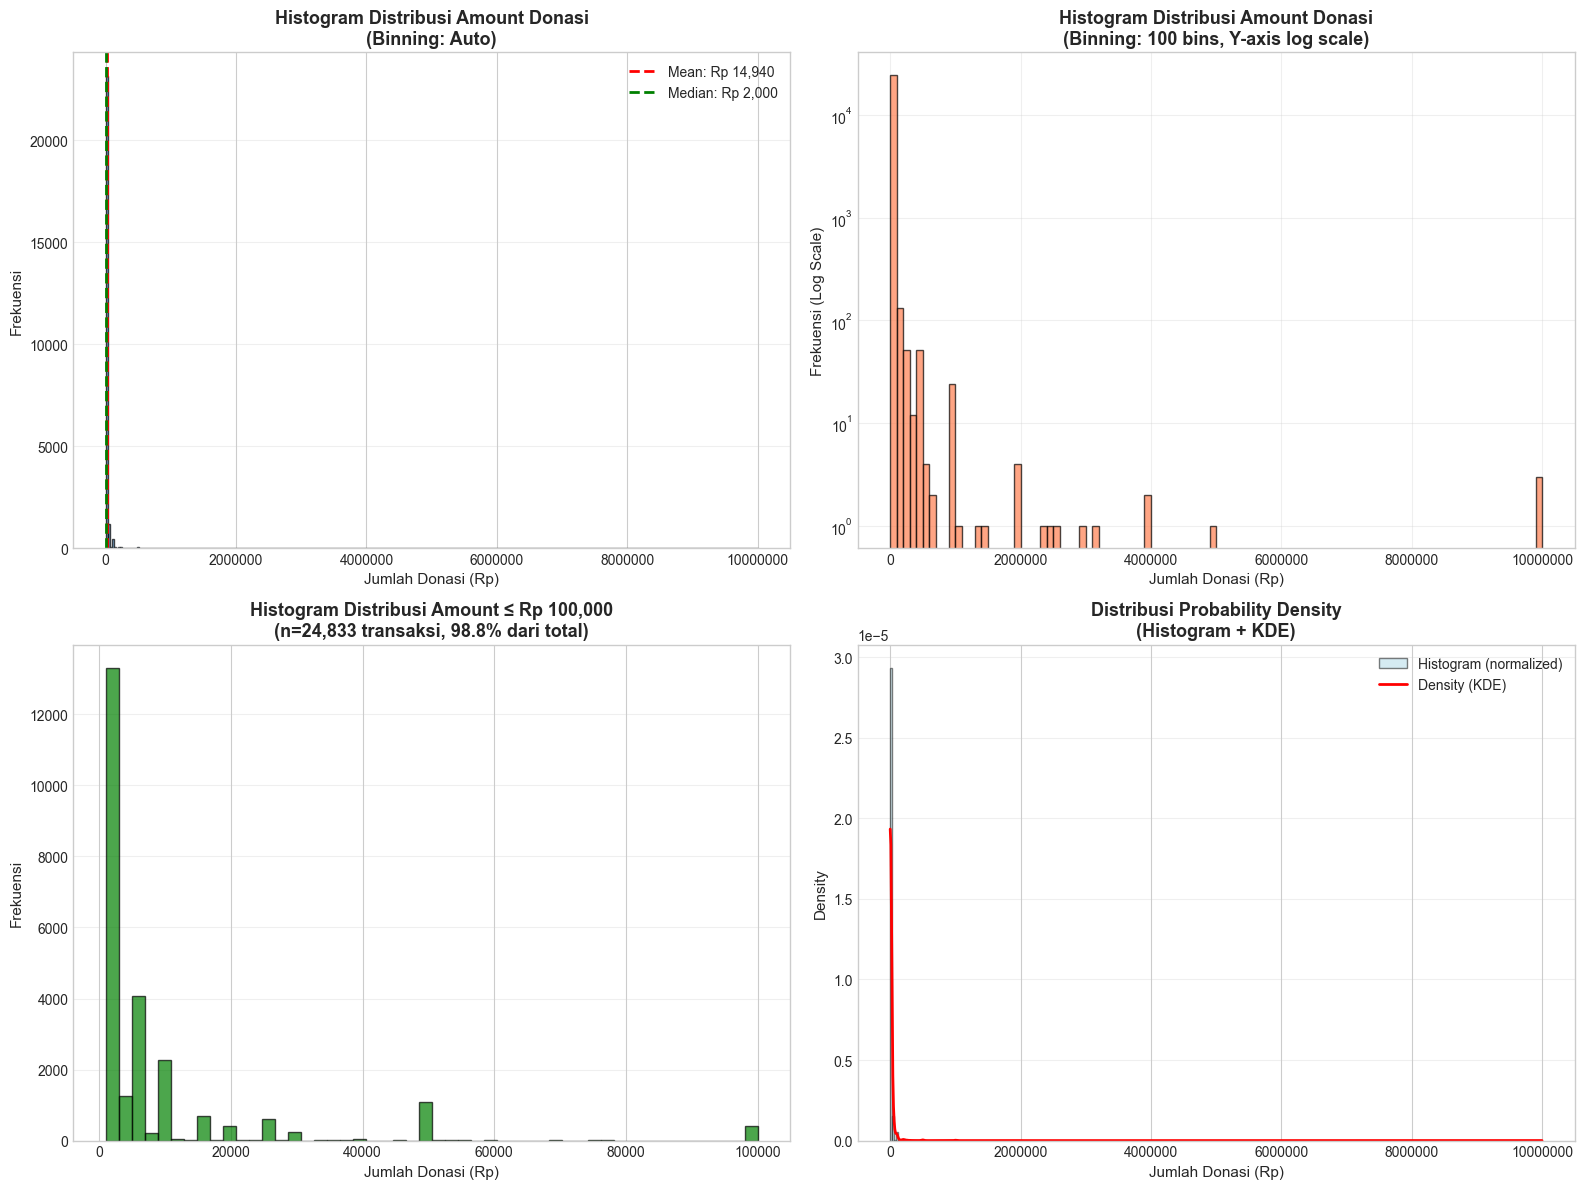

Grafik disimpan: histogram_distribusi_amount_keseluruhan.png

Statistik Keseluruhan:
  Total transaksi: 25,140
  Min: Rp 1,000
  Max: Rp 10,000,000
  Mean: Rp 14,939.84
  Median: Rp 2,000
  Std Dev: Rp 136,300.66


In [24]:
# Histogram distribusi amount untuk semua donasi (tanpa pemisahan per campaign)
# Menggunakan binning otomatis dari matplotlib

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram dengan binning otomatis (auto)
axes[0, 0].hist(df_clean['amount_numeric'], bins='auto', edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Histogram Distribusi Amount Donasi\n(Binning: Auto)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Donasi (Rp)', fontsize=11)
axes[0, 0].set_ylabel('Frekuensi', fontsize=11)
axes[0, 0].ticklabel_format(style='plain', axis='x')
axes[0, 0].grid(axis='y', alpha=0.3)

# Tambahkan statistik
axes[0, 0].axvline(df_clean['amount_numeric'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: Rp {df_clean["amount_numeric"].mean():,.0f}')
axes[0, 0].axvline(df_clean['amount_numeric'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: Rp {df_clean["amount_numeric"].median():,.0f}')
axes[0, 0].legend(loc='upper right')

# 2. Histogram dengan skala logaritmik untuk melihat detail di nilai kecil
axes[0, 1].hist(df_clean['amount_numeric'], bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title('Histogram Distribusi Amount Donasi\n(Binning: 100 bins, Y-axis log scale)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Donasi (Rp)', fontsize=11)
axes[0, 1].set_ylabel('Frekuensi (Log Scale)', fontsize=11)
axes[0, 1].set_yscale('log')
axes[0, 1].ticklabel_format(style='plain', axis='x')
axes[0, 1].grid(axis='both', alpha=0.3)

# 3. Histogram untuk range kecil (< Rp 100,000) - di mana mayoritas data berada
df_small = df_clean[df_clean['amount_numeric'] <= 100000]
axes[1, 0].hist(df_small['amount_numeric'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_title(f'Histogram Distribusi Amount ≤ Rp 100,000\n(n={len(df_small):,} transaksi, {len(df_small)/len(df_clean)*100:.1f}% dari total)', 
                     fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Donasi (Rp)', fontsize=11)
axes[1, 0].set_ylabel('Frekuensi', fontsize=11)
axes[1, 0].ticklabel_format(style='plain', axis='x')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Density plot (KDE) untuk melihat distribusi halus
from scipy import stats
axes[1, 1].hist(df_clean['amount_numeric'], bins='auto', density=True, alpha=0.5, edgecolor='black', color='lightblue', label='Histogram (normalized)')

# KDE plot
density = stats.gaussian_kde(df_clean['amount_numeric'])
xs = np.linspace(df_clean['amount_numeric'].min(), df_clean['amount_numeric'].max(), 1000)
axes[1, 1].plot(xs, density(xs), 'r-', linewidth=2, label='Density (KDE)')

axes[1, 1].set_title('Distribusi Probability Density\n(Histogram + KDE)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Jumlah Donasi (Rp)', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)
axes[1, 1].ticklabel_format(style='plain', axis='x')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('histogram_distribusi_amount_keseluruhan.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafik disimpan: histogram_distribusi_amount_keseluruhan.png")
print(f"\nStatistik Keseluruhan:")
print(f"  Total transaksi: {len(df_clean):,}")
print(f"  Min: Rp {df_clean['amount_numeric'].min():,.0f}")
print(f"  Max: Rp {df_clean['amount_numeric'].max():,.0f}")
print(f"  Mean: Rp {df_clean['amount_numeric'].mean():,.2f}")
print(f"  Median: Rp {df_clean['amount_numeric'].median():,.0f}")
print(f"  Std Dev: Rp {df_clean['amount_numeric'].std():,.2f}")